Author: Shaira Shafiquzzaman

Date: February 28, 2026

Purpose:

This project conducts an exploratory genomic analysis of gene expression data derived from microarray experiments involving leukemia patients (AML, ALL) and healthy controls. The 20 genes with the highest variance across samples are selected and visualized using a heatmap to explore whether groups of patients show similar expression patterns across genes. Principal Component Analysis (PCA) is then performed on the full gene expression dataset, including standardization and dimensionality reduction, to investigate whether samples cluster according to diagnosis.

Sources:
1. Project conception and workflow: PCA tutorial from DataCamp (How to Do Principal Component Analysis (PCA) in Python)
2. PCA conceptual understanding: educational materials explaining Principal Component Analysis and variance-based feature transformation (StatQuest, IBM Technology, Visually explained)
3. Gene expression dataset: Microarray Gene Expression Profiles for Leukemia Early Diagnosis Models, obtained from Kaggle
4. Data manipulation and preprocessing: pandas documentation
5. Data visualization: seaborn and matplotlib documentation
6. PCA implementation: scikit-learn documentation for PCA and StandardScaler

Environment Requirements: 
1. Python 3
2. Jupyter Notebook
3. Required packages: Pandas, Seaborn, NumPy, Matplotlib, Sklearn 

In [61]:
#install python packages
import pandas as pd
import seaborn as sns
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler 
from sklearn.decomposition import PCA

In [62]:
#import gene data and inspect first 5 rows 
gene_data = pd.read_csv('leukemia_gene_expression.csv')
print(gene_data.head())

#check dimensions of data and check for missing values
print(gene_data.shape)
print(gene_data.isnull().values.any())

     Gene_1    Gene_2    Gene_3    Gene_4    Gene_5    Gene_6    Gene_7  \
0  1.872701  4.753572  3.659970  2.993292  0.780093  0.779973  0.290418   
1  0.925665  2.709505  4.364729  3.661124  4.032806  3.293917  3.461383   
2  1.308528  1.234894  4.531273  1.247731  1.359749  3.796991  2.248699   
3  3.363515  3.983407  1.252339  3.124370  2.858730  4.164152  4.530435   
4  2.859979  4.027162  3.800805  0.769500  0.746247  1.340872  1.805374   

     Gene_8    Gene_9   Gene_10  ...  Gene_992  Gene_993  Gene_994  Gene_995  \
0  4.330881  3.005575  3.540363  ...  3.473482  1.360726  2.951153  1.804869   
1  4.245978  1.248340  2.447125  ...  0.794541  3.051126  0.676770  3.756875   
2  3.883553  0.326831  2.437856  ...  4.000017  2.763535  1.982768  0.658575   
3  0.060784  3.370100  0.259179  ...  1.055630  3.762342  0.256469  2.462677   
4  2.042278  3.398486  0.283402  ...  2.867816  1.708206  3.242323  0.342204   

   Gene_996  Gene_997  Gene_998  Gene_999  Gene_1000  Diagnosis  
0 

In [63]:
#compute the variance of each gene accross all participants. 
#genes with highest variance are selected because they are more likely to distinguish between patient groups
gene_features = gene_data.drop(columns = ['Diagnosis'])
variances = gene_features.var()

#find the 20 genes with the highest variance 
top_20_variances = variances.nlargest(20)
print(top_20_variances)

Gene_221    2.261985
Gene_166    2.250805
Gene_837    2.247405
Gene_555    2.246946
Gene_200    2.246386
Gene_595    2.245780
Gene_772    2.240272
Gene_29     2.227532
Gene_440    2.226748
Gene_639    2.225202
Gene_82     2.224283
Gene_151    2.223428
Gene_978    2.220198
Gene_876    2.218769
Gene_946    2.218092
Gene_439    2.217854
Gene_579    2.215395
Gene_149    2.215336
Gene_186    2.210144
Gene_932    2.205207
dtype: float64


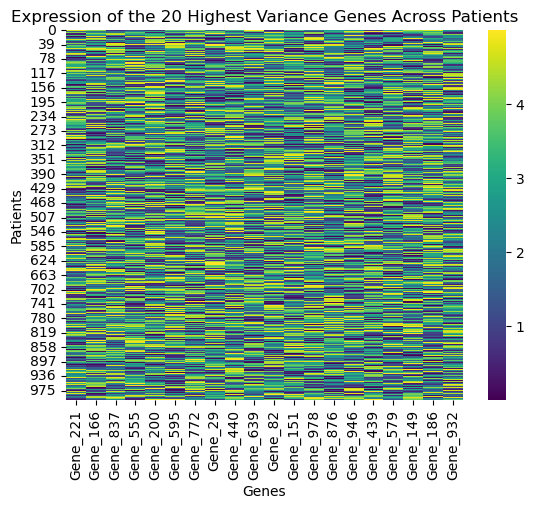

In [64]:
#create heatmap displaying the differences in expression in the 20 genes with the highest variance between patients
top_20_genes = gene_data[top_20_variances.index]
sns.heatmap(top_20_genes, cmap='viridis')
plt.xlabel('Genes')
plt.ylabel('Patients')
plt.title('Expression of the 20 Highest Variance Genes Across Patients')
plt.show()

In [65]:
#standardize the data so that mean is 0 and standard deviation is 1
#standardization ensures each gene contributes equally to PCA by removing scale differences
scaler = StandardScaler()
scaled_gene_array = scaler.fit_transform(gene_features)

#inspect shape of standardized data and check that mean and SD are correct
print(scaled_gene_array.shape)
print(np.mean(scaled_gene_array))
print(np.std(scaled_gene_array))

(1000, 1000)
2.9842794901924206e-19
1.0


In [66]:
#complete PCA analysis
scaled_gene_df = pd.DataFrame(data = scaled_gene_array, columns = gene_features.columns)
pca_genes = PCA(n_components = 2)
principal_components_genes = pca_genes.fit_transform(scaled_gene_array)

#create dataframe of principal components
principal_genes_df = pd.DataFrame(data = principal_components_genes, columns = ['principal component 1', 'principal component 2'])
print(principal_genes_df)

#interpret PCA
print('Explained variability per principal component: {}'.format(pca_genes.explained_variance_ratio_))

     principal component 1  principal component 2
0                -0.195037               0.915086
1                -0.262653              -1.925280
2                -0.355243               1.048477
3                 1.511915              -0.994980
4                -0.567505               4.113515
..                     ...                    ...
995               0.235407              -1.273873
996              -0.589453              -0.777500
997              -0.656341              -1.981076
998               0.340885               1.753117
999              -0.146708               6.573338

[1000 rows x 2 columns]
Explained variability per principal component: [0.0038039  0.00378107]


     principal component 1  principal component 2 Diagnosis
0                -0.195037               0.915086       AML
1                -0.262653              -1.925280       ALL
2                -0.355243               1.048477       ALL
3                 1.511915              -0.994980       AML
4                -0.567505               4.113515   Healthy
..                     ...                    ...       ...
995               0.235407              -1.273873       AML
996              -0.589453              -0.777500       ALL
997              -0.656341              -1.981076   Healthy
998               0.340885               1.753117       ALL
999              -0.146708               6.573338       ALL

[1000 rows x 3 columns]


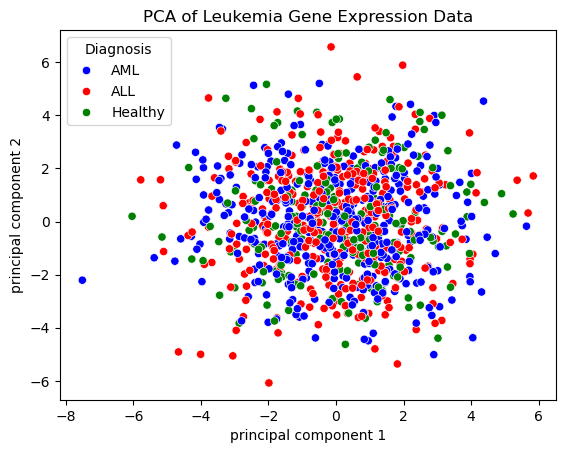

In [67]:
#add diagnosis column to principal_genes_df
principal_genes_df['Diagnosis'] = gene_data['Diagnosis']
print(principal_genes_df)

#visualize principal components 
sns.scatterplot(
    data = principal_genes_df,
    x = 'principal component 1',
    y = 'principal component 2',
    hue = 'Diagnosis',
    palette = ['blue', 'red', 'green']
)
plt.title('PCA of Leukemia Gene Expression Data')
plt.show()

Interpretation of Data:

The heatmap displays the expression levels of the 20 genes with the highest variance across patients, allowing for exploratory visualization of gene expression patterns. However, because patients are not explicitly labeled or clearly grouped by diagnosis in the visualization, interpretation with respect to disease categories is limited. Overall, the heatmap does not show strong or clearly defined patterns of expression across patients, suggesting that variation in these genes may be distributed more continuously rather than forming distinct groups.

Principal Component Analysis (PCA) was used to reduce the dimensionality of the gene expression data. Principal components are linear combinations of gene expression values that capture the greatest sources of variance in the dataset, with PC1 capturing the most variance and PC2 capturing the second most. The PCA plot shows that samples from different diagnosis groups largely overlap rather than forming clearly separated clusters. This suggests that while there may be underlying differences in gene expression between groups, these differences are not strongly captured by the first two principal components.

Limitations:
1. The heatmap does not clearly label or separate patients by diagnosis, limiting interpretation of disease-specific patterns
2. Only the top 20 most variable genes were included, potentially excluding biologically relevant but lower-variance genes
3. PCA is a linear method and may not capture more complex, nonlinear relationships in gene expression data
4. No formal statistical analysis (e.g., differential expression testing) was performed to assess significance
5. The analysis is exploratory and does not provide predictive or causal conclusions

Future Directions:
1. Perform differential expression analysis to identify genes significantly associated with each leukemia subtype
2. Apply nonlinear dimensionality reduction methods such as t-SNE or UMAP to better capture complex structure in the data
3. Incorporate machine learning models to classify leukemia subtypes based on gene expression profiles
4. Expand analysis to include additional genes or pathway-level analysis for deeper biological insight 
   